# Validation Visualization Dashboard

This notebook creates comprehensive visualizations from validation results.

**Prerequisites:** Run `python3 run_validation.py` first to generate metrics.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.validation.metrics import ValidationMetrics

import warnings
warnings.filterwarnings('ignore')

sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

# Output directory
output_dir = Path.cwd().parent / 'data/validation'
output_dir.mkdir(parents=True, exist_ok=True)

## 1. Load Validation Metrics

In [2]:
# Load validation metrics
metrics_file = output_dir / 'validation_metrics.csv'

if not metrics_file.exists():
    print("⚠️  No validation metrics found!")
    print("   Run: python3 run_validation.py")
else:
    print(f"Loading: {metrics_file.name}")
    df_metrics = pd.read_csv(metrics_file)
    print(f"✓ Loaded {len(df_metrics)} questions")
    
    print("\nMetrics preview:")
    print(df_metrics[['question', 'kl_divergence', 'ground_truth_mean', 'synthetic_mean']].head(10))

Loading: validation_metrics.csv
✓ Loaded 7 questions

Metrics preview:
    question  kl_divergence  ground_truth_mean  synthetic_mean
0   BELVBLTY       0.350280           3.027500        2.395556
1  EXCITMENT       2.701530           2.592500        1.697778
2   LIKBILTY       0.782182           3.713333        3.133333
3   PRPURINT       0.003942           3.214167        3.128889
4   PRVALMNY       0.371591           3.535000        2.720000
5   RELVANCE       1.371801           2.443333        3.955556
6   UNIQNESS       5.366471           3.640833        2.284444


## 2. Performance Summary

In [3]:
print("Overall Performance")
print("="*80)

mean_kl = df_metrics['kl_divergence'].mean()
print(f"\nMean KL Divergence: {mean_kl:.4f}")
print(f"  < 0.05 = Excellent ⭐")
print(f"  0.05-0.10 = Good ✓")
print(f"  0.10-0.20 = Acceptable")
print(f"  > 0.20 = Needs improvement")

print(f"\nMean KS Statistic: {df_metrics['ks_statistic'].mean():.4f}")
print(f"Mean Absolute Error: {df_metrics['mean_absolute_error'].mean():.4f}")

if len(df_metrics) > 2:
    corr = ValidationMetrics.correlation(
        df_metrics['ground_truth_mean'].values,
        df_metrics['synthetic_mean'].values
    )
    corr_att = ValidationMetrics.correlation_attainment(corr, 0, reliability=0.85)
    print(f"\nCorrelation: {corr:.4f}")
    print(f"Correlation Attainment: {corr_att:.1f}% (Target: >85%)")

print(f"\n✅ Best Performers:")
for idx, row in df_metrics.nsmallest(3, 'kl_divergence').iterrows():
    print(f"  {row['question']:12s} - KL: {row['kl_divergence']:.4f}")

print(f"\n⚠️  Need Improvement:")
for idx, row in df_metrics.nlargest(3, 'kl_divergence').iterrows():
    print(f"  {row['question']:12s} - KL: {row['kl_divergence']:.4f}")

Overall Performance

Mean KL Divergence: 1.5640
  < 0.05 = Excellent ⭐
  0.05-0.10 = Good ✓
  0.10-0.20 = Acceptable
  > 0.20 = Needs improvement

Mean KS Statistic: 0.3965
Mean Absolute Error: 0.8394

Correlation: -0.1007
Correlation Attainment: -11.8% (Target: >85%)

✅ Best Performers:
  PRPURINT     - KL: 0.0039
  BELVBLTY     - KL: 0.3503
  PRVALMNY     - KL: 0.3716

⚠️  Need Improvement:
  UNIQNESS     - KL: 5.3665
  EXCITMENT    - KL: 2.7015
  RELVANCE     - KL: 1.3718


## 3. KL Divergence Ranking

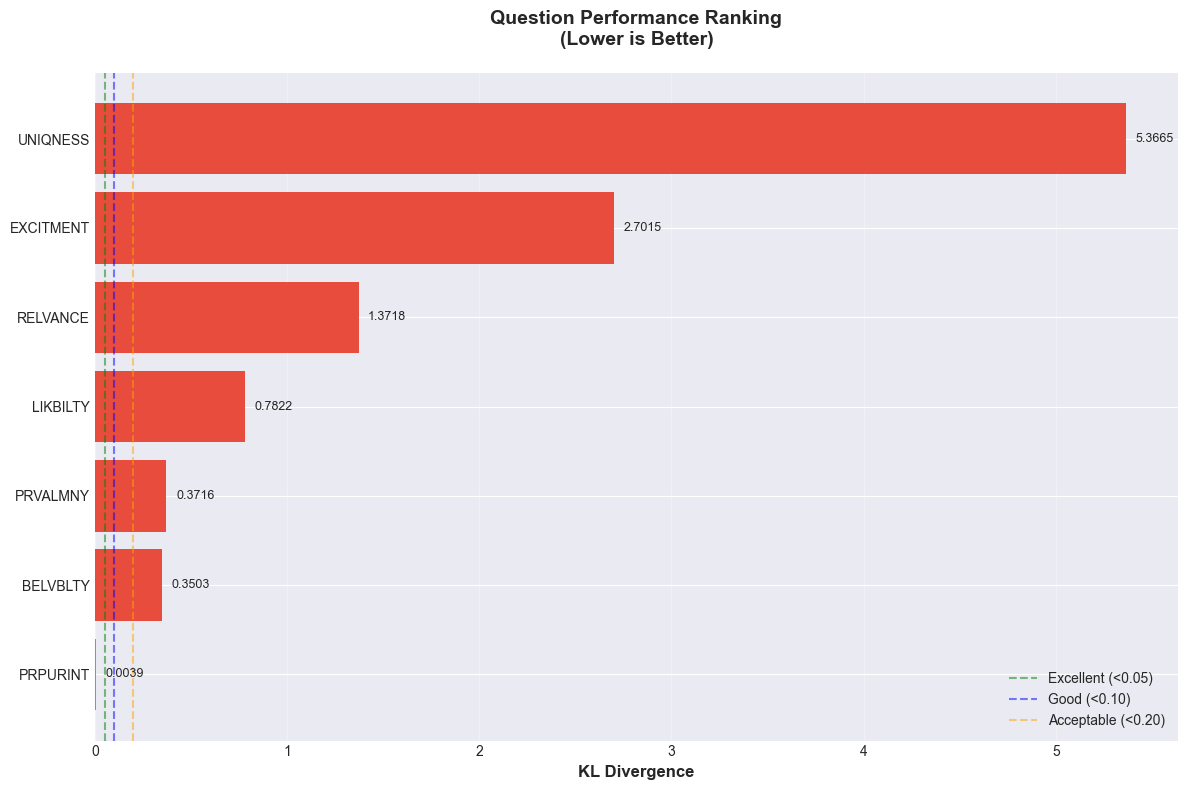

✓ Saved: kl_ranking.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

df_sorted = df_metrics.sort_values('kl_divergence')

# Color coding
colors = ['#2ecc71' if kl < 0.05 else '#3498db' if kl < 0.10 else '#f39c12' if kl < 0.20 else '#e74c3c' 
          for kl in df_sorted['kl_divergence']]

bars = ax.barh(range(len(df_sorted)), df_sorted['kl_divergence'], color=colors)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['question'])
ax.set_xlabel('KL Divergence', fontsize=12, fontweight='bold')
ax.set_title('Question Performance Ranking\n(Lower is Better)', fontsize=14, fontweight='bold', pad=20)

# Reference lines
ax.axvline(x=0.05, color='green', linestyle='--', alpha=0.5, label='Excellent (<0.05)')
ax.axvline(x=0.10, color='blue', linestyle='--', alpha=0.5, label='Good (<0.10)')
ax.axvline(x=0.20, color='orange', linestyle='--', alpha=0.5, label='Acceptable (<0.20)')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Value labels
for i, (bar, val) in enumerate(zip(bars, df_sorted['kl_divergence'])):
    ax.text(val + 0.05, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
fig.savefig(output_dir / 'kl_ranking.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: kl_ranking.png")

## 4. Distribution Comparison Grid

Loaded GT: 400 rows
Loaded Synthetic: 75 rows


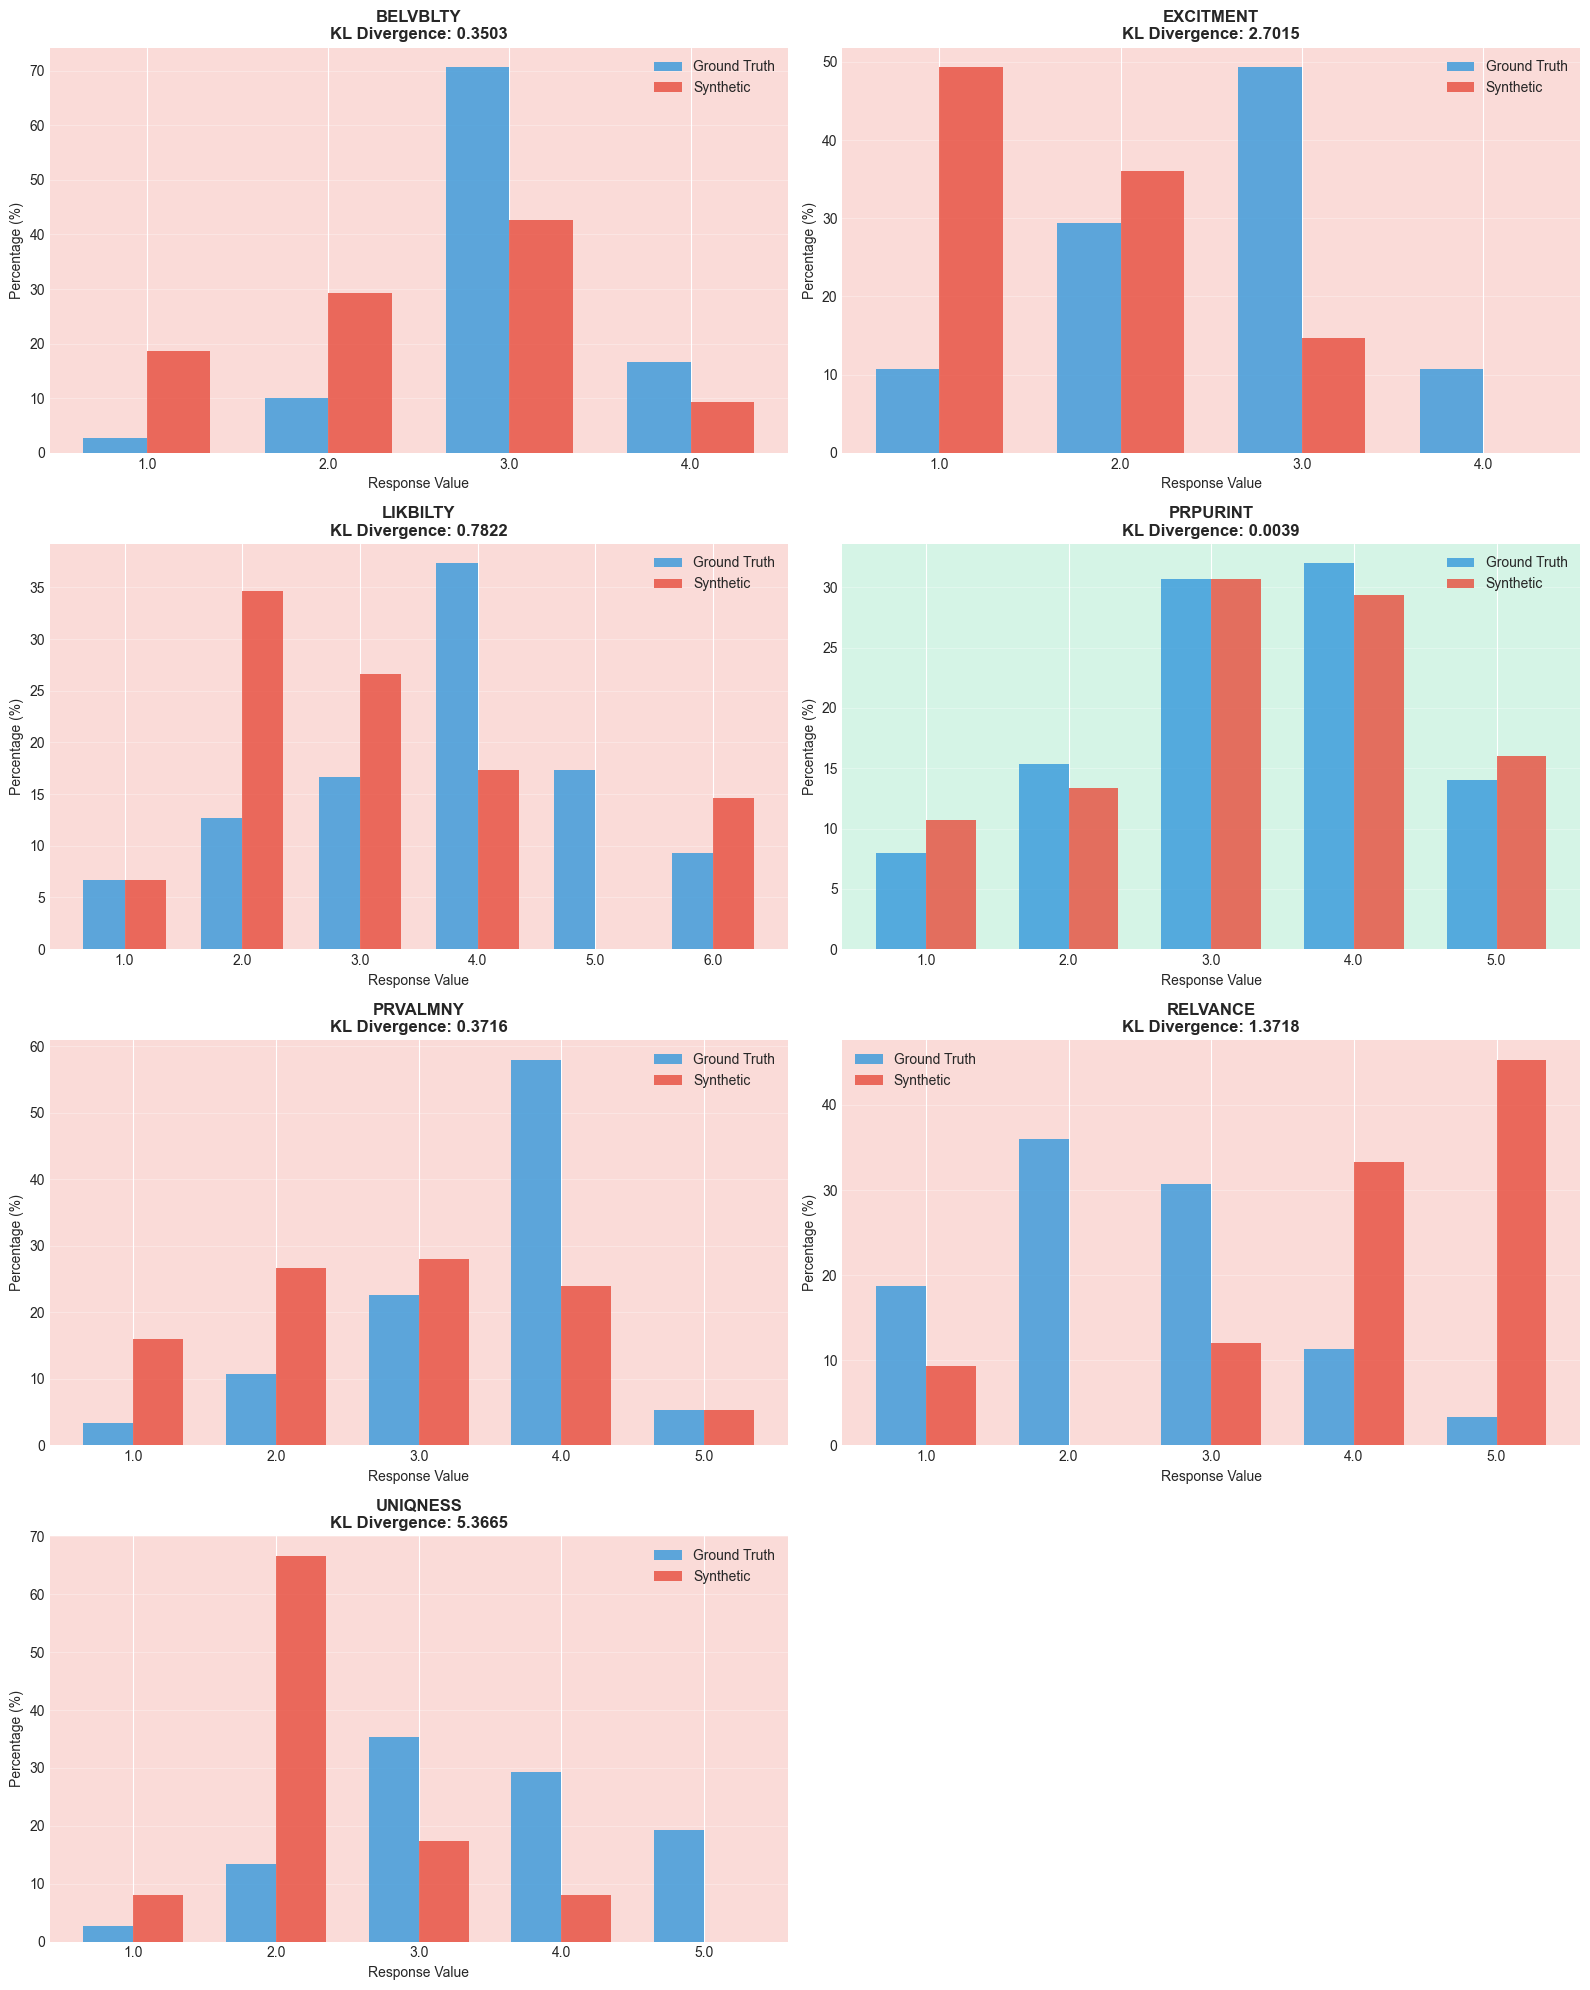

✓ Saved: distribution_grid.png


In [5]:
# Load the actual data for distribution plots
synthetic_dir = Path.cwd().parent / 'data/synthetic'
gt_path = Path.cwd().parent / 'source docs/KAP400232611_Respondent_Data_Tech Enabled CZ.xlsx'

synthetic_files = list(synthetic_dir.glob('synthetic_data_*.xlsx'))
if synthetic_files:
    synthetic_file = sorted(synthetic_files, key=lambda f: f.stat().st_mtime)[-1]
    df_synthetic = pd.read_excel(synthetic_file, sheet_name=0)
    df_gt = pd.read_excel(gt_path, sheet_name=0)
    
    print(f"Loaded GT: {len(df_gt)} rows")
    print(f"Loaded Synthetic: {len(df_synthetic)} rows")
    
    # Helper function
    def extract_numeric(series):
        def parse(val):
            if pd.isna(val): return np.nan
            s = str(val)
            if s.startswith('(') and ')' in s:
                try: return int(s.split(')')[0][1:])
                except: return np.nan
            try: return float(s)
            except: return np.nan
        return series.apply(parse)
    
    # Create grid
    questions = df_metrics['question'].tolist()
    n_questions = len(questions)
    n_cols = 2
    n_rows = (n_questions + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_questions > 1 else [axes]
    
    for idx, question in enumerate(questions):
        ax = axes[idx]
        
        # Find columns
        gt_col = [c for c in df_gt.columns if question in c][0] if any(question in c for c in df_gt.columns) else None
        syn_col = [c for c in df_synthetic.columns if question in c][0] if any(question in c for c in df_synthetic.columns) else None
        
        if gt_col and syn_col:
            gt_data = extract_numeric(df_gt[gt_col]).dropna()
            syn_data = extract_numeric(df_synthetic[syn_col]).dropna()
            
            # Percentages
            gt_pct = gt_data.value_counts(normalize=True).sort_index() * 100
            syn_pct = syn_data.value_counts(normalize=True).sort_index() * 100
            
            all_vals = sorted(set(gt_pct.index) | set(syn_pct.index))
            gt_vals = [gt_pct.get(v, 0) for v in all_vals]
            syn_vals = [syn_pct.get(v, 0) for v in all_vals]
            
            x = np.arange(len(all_vals))
            width = 0.35
            
            ax.bar(x - width/2, gt_vals, width, label='Ground Truth', alpha=0.8, color='#3498db')
            ax.bar(x + width/2, syn_vals, width, label='Synthetic', alpha=0.8, color='#e74c3c')
            
            kl = df_metrics[df_metrics['question'] == question]['kl_divergence'].values[0]
            
            ax.set_xlabel('Response Value', fontsize=10)
            ax.set_ylabel('Percentage (%)', fontsize=10)
            ax.set_title(f'{question}\nKL Divergence: {kl:.4f}', fontsize=12, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(all_vals)
            ax.legend()
            ax.grid(axis='y', alpha=0.3)
            
            # Background color
            if kl < 0.05:
                ax.set_facecolor('#d5f4e6')
            elif kl < 0.10:
                ax.set_facecolor('#d6eaf8')
            elif kl < 0.20:
                ax.set_facecolor('#fdebd0')
            else:
                ax.set_facecolor('#fadbd8')
    
    # Hide unused
    for idx in range(n_questions, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    fig.savefig(output_dir / 'distribution_grid.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: distribution_grid.png")
else:
    print("⚠️  No synthetic data found for distribution plots")

## Summary

✅ **Visualizations Created:**
- KL Divergence ranking chart (color-coded by performance)
- Distribution comparison grid (all questions side-by-side)

All outputs saved to `data/validation/`